# Ekush Bangla Digits — Model Analysis (Notebook 1 of 2)

**Modular edition: all state lives in Google Drive, and each stage runs on its own.**

---

This notebook audits the Ekush numeral benchmark with models alone. It asks:

1. **Is the test set clean?** Exact duplicates removed, near-duplicates between train and test detected and confirmed.
2. **Are the architecture rankings statistically resolved?** Several seeds per architecture, seed noise compared against architecture gaps, paired tests with confidence intervals.
3. **Do the models know when they are wrong?** Calibration, ensemble uncertainty, error detection, selective prediction.
4. **Which stored labels look wrong?** Confident learning on out-of-sample predictions for every image.

It then freezes a **study package** for Notebook 2 (`Ekush_Human_Study.ipynb`).

## How this edition is organised

- **All logic lives in `ekush_core.py`,** kept next to this notebook in the Drive study folder. The cells below are thin: each calls one function. To change a method, edit the module, then `Runtime → Restart session` and run again.
- **Everything durable is written to Drive** as soon as it is produced: checkpoints, predictions, splits, tables, figures and the study package. A Colab disconnect costs at most the run in progress.
- **Stages are independent.** Each stage loads what it needs from Drive rather than from variables in memory, so you can run analysis in a fresh CPU session without retraining.

| Stage | Flag | Needs a GPU | Typical time |
| --- | --- | --- | --- |
| Data and splits | always | no | ~2 min (first run only) |
| Training | `RUN_TRAINING` | yes | ~20 min per run |
| Analysis | `RUN_ANALYSIS` | no | ~3 min |
| Label issues | `RUN_LABEL_ISSUES` | yes (first time) | ~15 min, then cached |
| Study package | `RUN_PACKAGE` | no | ~1 min |

## Before the first run

Put `ekush_core.py` in `MyDrive/ekush_study/` (create the folder), then run all. Set `max_runs_this_session` if your Colab sessions are short: training stops cleanly after that many runs and tells you what is left.

If an earlier session trained models into `/content`, the migration cell copies them into Drive so that work is not lost.

## 1. Setup

In [ ]:
import importlib, subprocess, sys
REQUIRED = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "sklearn": "scikit-learn", "scipy": "scipy",
            "PIL": "pillow", "tqdm": "tqdm", "cleanlab": "cleanlab"}
missing = [p for m, p in REQUIRED.items() if importlib.util.find_spec(m) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("Dependencies ready.")

Dependencies ready.


In [ ]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# The study folder holds ekush_core.py and every artefact this notebook creates.
DRIVE_ROOT = os.environ.get("EKUSH_DRIVE_ROOT", "/content/drive/MyDrive/ekush_study")

if "google.colab" in sys.modules:
    from google.colab import drive as _drive
    if not Path("/content/drive/MyDrive").is_dir():
        _drive.mount("/content/drive")
Path(DRIVE_ROOT).mkdir(parents=True, exist_ok=True)
sys.path.insert(0, DRIVE_ROOT)

try:
    import ekush_core as ek
except ModuleNotFoundError:
    raise SystemExit(f"ekush_core.py not found in {DRIVE_ROOT}. "
                     "Upload it there (same folder as this notebook's study folder) and re-run.")

import importlib as _il
ek = _il.reload(ek)          # pick up edits to the module without a fresh runtime
ek.style_plots()
import tensorflow as tf, keras, platform
print(f"ekush_core {ek.__version__} | Python {platform.python_version()} | "
      f"TensorFlow {tf.__version__} | Keras {keras.__version__}")

ekush_core 1.0 | Python 3.13.15 | TensorFlow 2.20.0 | Keras 3.13.2


In [ ]:
CFG = ek.Config(
    drive_root=DRIVE_ROOT,
    # --- edit anything here; defaults are in ekush_core.Config ---
    architectures=("xception", "resnet50v2", "mobilenetv2", "efficientnetb0", "custom_cnn"),
    seeds=(13, 42, 2024),
    headline_arch="xception",
    epochs=15,
    max_runs_this_session=0,     # e.g. 4 if your Colab session is short; 0 = no limit
)
ek.mount_drive(CFG)
GPUS = ek.enable_mixed_precision(CFG)
print(f"GPU: {GPUS or 'none (CPU only — training stages will be slow)'}")

# Stage switches. Analysis and the package need no GPU.
RUN_MIGRATION    = True    # copy runs from an earlier /content session into Drive
RUN_TRAINING     = True
RUN_ANALYSIS     = True
RUN_LABEL_ISSUES = True
RUN_PACKAGE      = True

Drive mounted. Study folder: /content/drive/MyDrive/ekush_study
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data, Splits, and Test-Set Hygiene

The dataset arrays are cached on Drive and the images are written to local disk for speed. Splits are created once, saved to Drive, and fingerprinted; every checkpoint records the fingerprint, so a run trained on a different split can never be mixed in.

Near-duplicates between train and test are found with a difference hash and confirmed by pixel correlation. Different writers' digits can look alike, so confirmed pairs are shown for inspection, and accuracy is also reported with them removed.

In [ ]:
ek.acquire_dataset(CFG, progress=tqdm)
frames, SPLIT = ek.build_or_load_splits(CFG, progress=tqdm)
arrays = {k: (ek.load_images(frames[k], progress=tqdm), frames[k]["class_idx"].to_numpy())
          for k in ("train", "val", "test")}
X_train, y_train = arrays["train"]
X_val, y_val = arrays["val"]
X_test, y_test = arrays["test"]
N_TEST = len(y_test)
print(json.dumps(SPLIT, indent=2))

Image tree present at /content/ekush_local/data/ekush_digits
Loaded existing splits from /content/drive/MyDrive/ekush_study/splits (test SHA-256 b67330bc40a2bb5e...)


Loading:   0%|          | 0/24189 [00:00<?, ?it/s]

Loading:   0%|          | 0/3024 [00:00<?, ?it/s]

Loading:   0%|          | 0/3024 [00:00<?, ?it/s]

{
  "raw_images": 30687,
  "exact_duplicates_removed": 450,
  "n_train": 24189,
  "n_val": 3024,
  "n_test": 3024,
  "test_split_sha256": "b67330bc40a2bb5e9541b24e4f902419fc0d65e2a1753f7aa09c75cf8ad070d8",
  "split_sha256": "3cda831ba0d3297c2d5152fb43ca788d41ca81028242ecb247a77c6c8015194d",
  "split_seed": 42,
  "created_utc": "2026-09-19T03:45:14Z"
}


In [ ]:
if RUN_MIGRATION:
    ek.migrate_local_outputs(CFG, SPLIT)

Nothing to migrate from /content/ekush_model_analysis.


dHash candidate pairs: 9,066 | confirmed pairs: 1
Test images with a confirmed near-duplicate in train: 1 of 3,024 (0.03%, 95% CI 0.01-0.19%)
  pairs whose train copy has a DIFFERENT label: 0


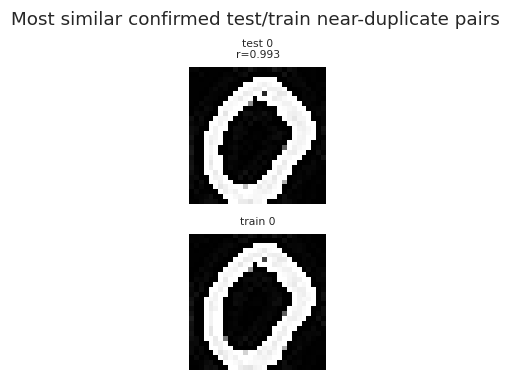

In [ ]:
near, NEAR_DUP_TEST, n_cand = ek.near_duplicates(
    CFG, X_train, X_test, y_train, y_test,
    frames["train"]["rel_key"].to_numpy(), frames["test"]["rel_key"].to_numpy())
n_nd = int(NEAR_DUP_TEST.sum())
lo, hi = ek.wilson(n_nd, N_TEST)
print(f"dHash candidate pairs: {n_cand:,} | confirmed pairs: {len(near):,}")
print(f"Test images with a confirmed near-duplicate in train: {n_nd} of {N_TEST:,} "
      f"({100 * n_nd / N_TEST:.2f}%, 95% CI {100 * lo:.2f}-{100 * hi:.2f}%)")
if len(near):
    print(f"  pairs whose train copy has a DIFFERENT label: "
          f"{int((near['test_label'] != near['train_label']).sum())}")
    ek.plot_near_duplicates(CFG, near, X_train, X_test)
    plt.show()
NEAR_INFO = {"near_dup_candidate_pairs": n_cand, "near_dup_confirmed_pairs": len(near),
             "test_near_duplicates": n_nd}

## 3. Training

Every architecture takes raw 28×28 input and does its own resizing, channel replication and scaling inside the model, so a saved checkpoint needs no external preprocessing.

Each finished run is written to Drive immediately and verified by hash, and finished runs are skipped on re-execution. A run that fails the validation-accuracy gate stops the notebook instead of being saved.

In [ ]:
if RUN_TRAINING:
    RUN_INFO, REMAINING = ek.run_training(CFG, frames, arrays, SPLIT)
    if REMAINING:
        raise ek.StopExecution(
            f"Training paused with {len(REMAINING)} run(s) left: {REMAINING}\n"
            "Everything finished is on Drive. Re-run this notebook to continue.")
else:
    RUN_INFO, missing, _ = ek.training_status(CFG, SPLIT)
    print(f"Training skipped. On Drive: {len(RUN_INFO)} run(s); missing: {missing or 'none'}")

  xception_s13             on Drive  test acc 0.9921
  xception_s42             on Drive  test acc 0.9884
  xception_s2024           on Drive  test acc 0.9937
  resnet50v2_s13           on Drive  test acc 0.9954
  resnet50v2_s42           on Drive  test acc 0.9931
  resnet50v2_s2024         on Drive  test acc 0.9924
  mobilenetv2_s13          on Drive  test acc 0.9907
  mobilenetv2_s42          on Drive  test acc 0.9897
  mobilenetv2_s2024        on Drive  test acc 0.9907
  efficientnetb0_s13       on Drive  test acc 0.9871
  efficientnetb0_s42       trained   test acc 0.9871 (13 epochs, 520s) -> Drive
  efficientnetb0_s2024     trained   test acc 0.9874 (15 epochs, 448s) -> Drive
  custom_cnn_s13           trained   test acc 0.9934 (15 epochs, 73s) -> Drive
  custom_cnn_s42           trained   test acc 0.9921 (15 epochs, 66s) -> Drive
  custom_cnn_s2024         trained   test acc 0.9904 (15 epochs, 65s) -> Drive

All 15 runs complete.


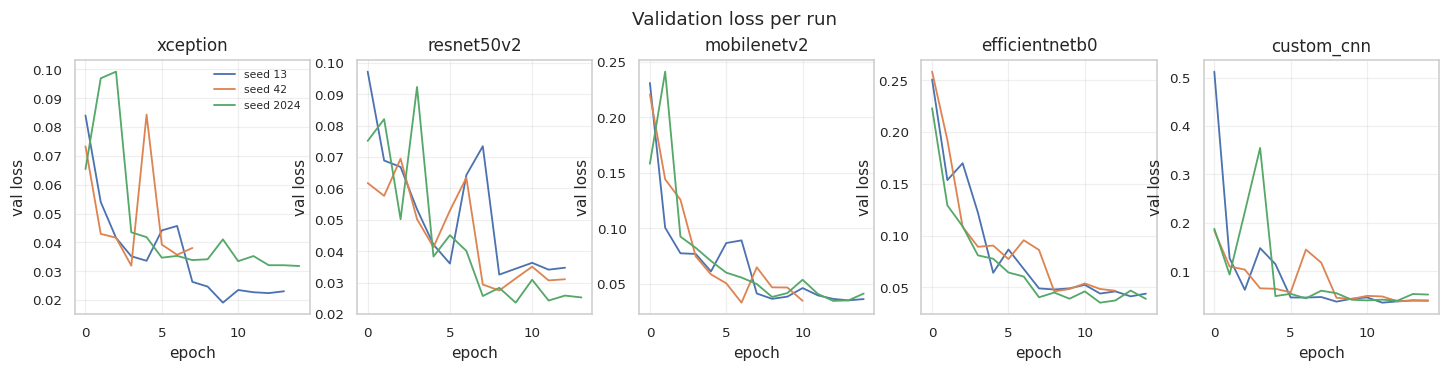

                                arch  seed epochs_run train_seconds   val_acc  test_acc
xception_s13                xception    13         14        1263.5  0.996362  0.992063
xception_s42                xception    42          8         726.4   0.99041  0.988426
xception_s2024              xception  2024         15        1241.6  0.992394  0.993717
resnet50v2_s13            resnet50v2    13         13         697.3  0.992725   0.99537
resnet50v2_s42            resnet50v2    42         13         641.6  0.993386  0.993056
resnet50v2_s2024          resnet50v2  2024         14         691.1  0.993056  0.992394
mobilenetv2_s13          mobilenetv2    13         15         396.3  0.992063  0.990741
mobilenetv2_s42          mobilenetv2    42         11         271.1  0.990741  0.989749
mobilenetv2_s2024        mobilenetv2  2024         15         329.8  0.991071  0.990741
efficientnetb0_s13    efficientnetb0    13         15         487.5  0.987765  0.987103
efficientnetb0_s42    efficientn

In [ ]:
TAGS, PV, PT, RUN_INFO = ek.load_predictions(CFG, SPLIT)
ek.plot_training_curves(CFG, RUN_INFO)
plt.show()
print(pd.DataFrame(RUN_INFO).T[["arch", "seed", "epochs_run", "train_seconds",
                                "val_acc", "test_acc"]].to_string())

## 4. Are the Architecture Rankings Statistically Resolved?

Three levels of evidence, from weakest to strongest:

1. **Per-run accuracy** with Wilson intervals, and mean ± sd across seeds.
2. **Seed noise vs architecture gap.** Two runs of the same architecture differing only in seed still disagree on some test images. If different architectures disagree about as often, published gaps sit inside run-to-run noise.
3. **Paired comparisons of seed-averaged models:** bootstrap CIs on the difference, exact McNemar tests with Holm correction, the fraction of seed pairings in which A beats B, and the bootstrap probability of ranking first.

Per-architecture accuracy (seed-ensemble = mean of seed probabilities)

                Params (M)  Seed mean acc  Seed sd  Seed range (pp)        Seed-ensemble acc  No near-dups  P(rank 1) Rank 95% interval
Architecture                                                                                                                           
resnet50v2        23.58529        0.99361  0.00156          0.29762  0.9964 [0.9940, 0.9983]       0.99636     0.8384               1-2
mobilenetv2        2.27079        0.99041  0.00057          0.09921  0.9954 [0.9927, 0.9977]       0.99537     0.2200               1-3
xception          20.88197        0.99140  0.00271          0.52910  0.9940 [0.9911, 0.9967]       0.99405     0.0392               1-4
custom_cnn         0.28907        0.99195  0.00149          0.29762  0.9931 [0.9897, 0.9960]       0.99305     0.0032               2-5
efficientnetb0     4.06238        0.98721  0.00019          0.03307  0.9904 [0.9868, 0.9937]       0.99041     0

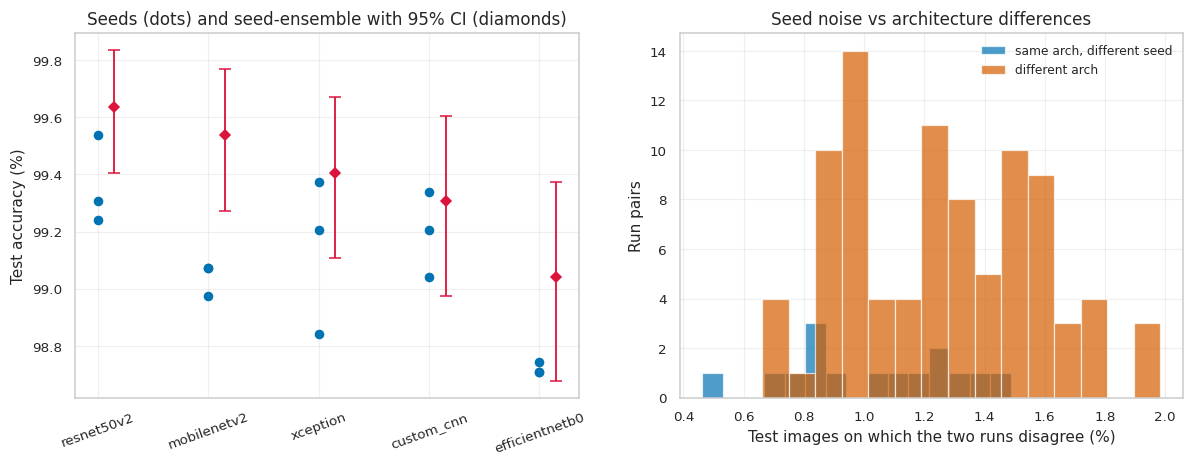

In [ ]:
if RUN_ANALYSIS:
    BENCH = ek.benchmark_stats(CFG, TAGS, PT, RUN_INFO, y_test, NEAR_DUP_TEST)
    print("Per-architecture accuracy (seed-ensemble = mean of seed probabilities)\n")
    print(BENCH["arch"].drop(columns="_acc").round(5).to_string())
    print("\nPrediction disagreement between runs\n")
    print(BENCH["noise"].round(5).to_string())
    print(f"\nMann-Whitney (between > within): p = {BENCH['noise_p']:.4g} "
          "(descriptive: run pairs share test images)")
    if len(BENCH["pairwise"]):
        n_sig = int(BENCH["pairwise"]["Significant"].sum())
        print(f"\nPairwise comparisons ({n_sig} of {len(BENCH['pairwise'])} significant "
              "after Holm)\n")
        print(BENCH["pairwise"].round(4).to_string(index=False))
    ek.plot_ranking(CFG, BENCH)
    plt.show()

## 5. Calibration

ECE, NLL and Brier score, per run, before and after temperature scaling fitted on the validation split. At 99% accuracy ECE rests on very few low-confidence images, so NLL is the more stable summary.

Calibration on the test split (mean ± sd over seeds; TS = temperature scaled)

                              T              ECE         ECE (TS)              NLL         NLL (TS)            Brier       Brier (TS)
Architecture                                                                                                                         
custom_cnn      0.9029 ± 0.0550  0.0067 ± 0.0020  0.0047 ± 0.0017  0.0365 ± 0.0013  0.0354 ± 0.0006  0.0149 ± 0.0009  0.0145 ± 0.0010
efficientnetb0  1.0927 ± 0.0399  0.0041 ± 0.0016  0.0036 ± 0.0011  0.0468 ± 0.0027  0.0461 ± 0.0030  0.0199 ± 0.0005  0.0198 ± 0.0006
mobilenetv2     1.0693 ± 0.1592  0.0042 ± 0.0008  0.0039 ± 0.0002  0.0342 ± 0.0012  0.0336 ± 0.0014  0.0148 ± 0.0019  0.0149 ± 0.0017
resnet50v2      1.1180 ± 0.0195  0.0027 ± 0.0009  0.0035 ± 0.0010  0.0246 ± 0.0033  0.0246 ± 0.0027  0.0099 ± 0.0015  0.0099 ± 0.0014
xception        1.1327 ± 0.1717  0.0041 ± 0.0004  0.0034 ± 0.0004  0.0331 ± 0.0070  0.0321 ± 0.0080  0.0143 ± 0.0038 

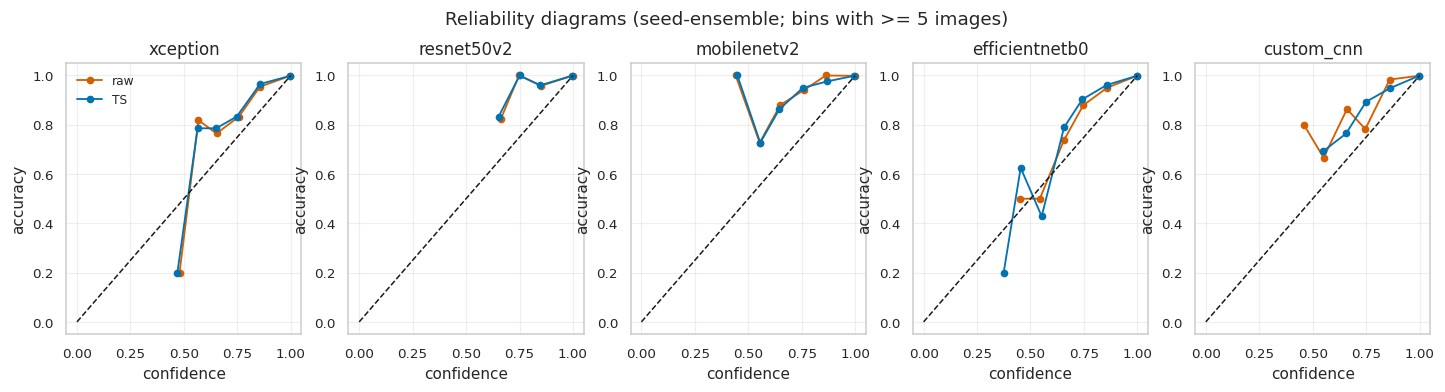

In [ ]:
if RUN_ANALYSIS:
    CAL, CAL_VIEW, TEMPS = ek.calibration_stats(CFG, TAGS, PV, PT, y_val, y_test)
    print("Calibration on the test split (mean ± sd over seeds; TS = temperature scaled)\n")
    print(CAL_VIEW.to_string())
    ek.plot_reliability(CFG, BENCH["arch_pt"], PT, TEMPS, y_test)
    plt.show()

## 6. Do the Models Know When They Are Wrong?

All runs form one deep ensemble. **Aleatoric** uncertainty is the mean entropy of the members (every run finds the image ambiguous); **epistemic** uncertainty is the mutual information (confident runs disagree). Each score is judged by error-detection AUROC, the risk–coverage curve, and the coverage attainable at the target accuracy.

Ensemble of 15 runs: accuracy 0.9967, 10 errors

                                                        Error AUROC  AURC (x1000)  Coverage at >= 99.9% acc
Score                                                                                                      
1 - max softmax (xception_s13, own errors)  0.9271 [0.8442, 0.9892]        0.9756                    0.9322
Epistemic (MI)                              0.8962 [0.7565, 0.9962]        0.4910                    0.9788
Negative margin                             0.8921 [0.7423, 0.9977]        0.5314                    0.9894
Variation ratio                             0.8921 [0.7376, 0.9967]        0.2866                    0.9891
Total entropy                               0.8835 [0.7282, 0.9948]        0.5844                    0.9831
Aleatoric                                   0.8775 [0.7206, 0.9913]        0.6132                    0.9610

Images misclassified by at least half of all runs: 11
Share of all run-level errors in

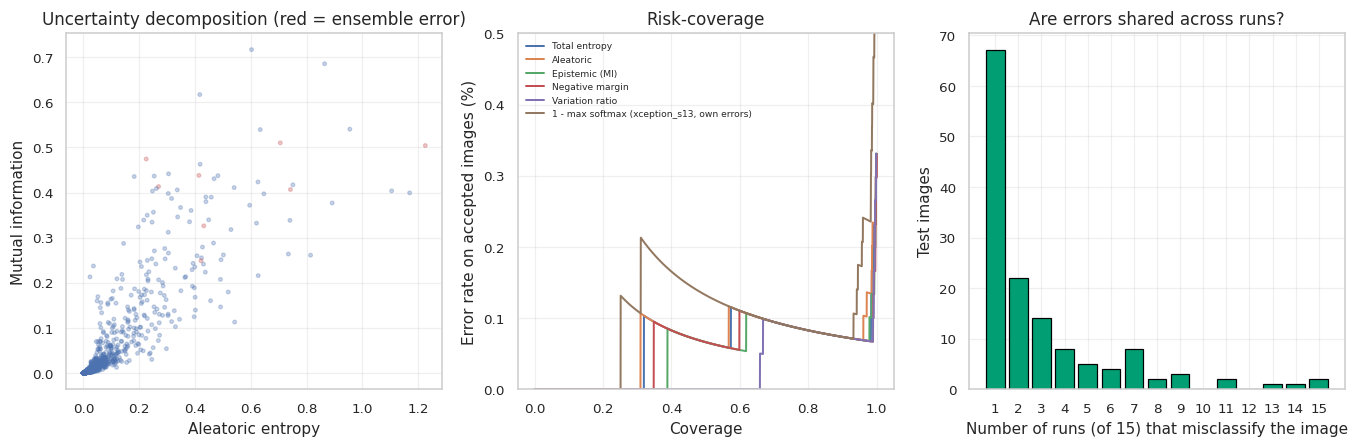

In [ ]:
if RUN_ANALYSIS:
    UNC = ek.uncertainty_scores(CFG, TAGS, PT, y_test)
    UNC_TAB = ek.uncertainty_stats(CFG, UNC, BENCH["bidx"])
    print(f"Ensemble of {len(TAGS)} runs: accuracy {1 - UNC['ens_err'].mean():.4f}, "
          f"{int(UNC['ens_err'].sum())} errors\n")
    print(UNC_TAB.drop(columns="_auc").round(4).to_string())
    hard = UNC["wrong_frac"] >= 0.5
    print(f"\nImages misclassified by at least half of all runs: {int(hard.sum())}")
    print(f"Share of all run-level errors in that hard core: "
          f"{(UNC['wrong_frac'] * hard).sum() / max(UNC['wrong_frac'].sum(), 1e-12):.3f}")
    ek.plot_uncertainty(CFG, UNC, len(TAGS))
    plt.show()

## 7. Label-Issue Candidates (Confident Learning)

An image is flagged when an out-of-sample model is confidently sure it belongs to a class other than its stored label. Train and validation images get cross-validated predictions (cached on Drive); test images already have out-of-sample predictions from the ensemble.

These are **candidates, not confirmed errors**: a candidate may be genuinely ambiguous, or simply misread by the models. Notebook 2 measures how many human readers actually reject.

  fold 1/5: held-out acc 0.9877
  fold 2/5: held-out acc 0.9879
  fold 3/5: held-out acc 0.9901
  fold 4/5: held-out acc 0.9855
  fold 5/5: held-out acc 0.9882
Cross-validated custom_cnn accuracy on train+val: 0.9879

           Images  Candidates  Rate (%)  95% CI low  95% CI high
Part                                                            
train+val   27213          40     0.147       0.108        0.200
test         3024           2     0.066       0.018        0.241

Sensitivity of seed-ensemble accuracy (candidates are UNVALIDATED)

                Full test set  Without CL candidates  Without near-dups  Rank (full)  Rank (no candidates)
xception              0.99405                0.99471            0.99405            3                     3
resnet50v2            0.99636                0.99702            0.99636            1                     1
mobilenetv2           0.99537                0.99603            0.99537            2                     2
efficientnetb0        0.9

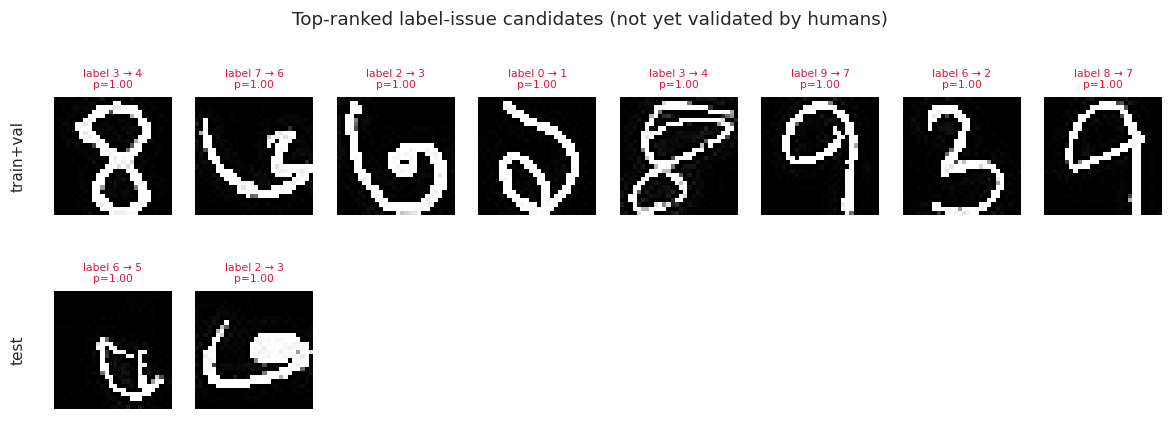

In [ ]:
if RUN_LABEL_ISSUES:
    pool_X = np.concatenate([X_train, X_val])
    pool_y = np.concatenate([y_train, y_val])
    pool_keys = np.concatenate([frames["train"]["rel_key"], frames["val"]["rel_key"]])
    OOF = ek.cross_val_predictions(CFG, pool_X, pool_y, SPLIT)
    print(f"Cross-validated {CFG.cl_arch} accuracy on train+val: "
          f"{(OOF.argmax(1) == pool_y).mean():.4f}\n")
    CL_POOL, CL_TEST, CL_SUMMARY = ek.confident_learning(
        CFG, OOF, pool_y, pool_keys, UNC["p_bar"], y_test, frames["test"]["rel_key"].to_numpy())
    print(CL_SUMMARY.round(3).to_string())
    SENS, CAND_MASK = ek.accuracy_sensitivity(CFG, BENCH["arch_correct"], CL_TEST,
                                              NEAR_DUP_TEST, N_TEST)
    ERR_IN_CAND = float(CAND_MASK[UNC["ens_err"]].mean()) if UNC["ens_err"].any() else float("nan")
    print("\nSensitivity of seed-ensemble accuracy (candidates are UNVALIDATED)\n")
    print(SENS.round(5).to_string())
    print(f"\nShare of ensemble test errors that are candidates: {ERR_IN_CAND:.3f}")
    ek.plot_label_issues(CFG, CL_POOL, CL_TEST, pool_X, X_test)
    plt.show()

## 8. Freeze the Study Package for Notebook 2

The test split is divided into **disjoint strata covering it completely**: a census of the top label-issue candidates (`cl`), a census of the most ambiguous remaining images (`high`), a sample from the next band (`mid`), and a sample from the rest (`low`, which also supplies attention checks).

The package holds the item manifest with an MD5 per image, the attention checks, the per-run test probabilities, the run table with checkpoint hashes, and the pre-registered thresholds. Every file is hashed into `package_manifest.json`. Once frozen it is verified, never regenerated.

In [ ]:
if RUN_PACKAGE:
    # Stages are independent: rebuild anything this one needs but does not have.
    if "UNC" not in globals():
        UNC = ek.uncertainty_scores(CFG, TAGS, PT, y_test)
    if "CL_TEST" not in globals():
        CL_TEST = ek.load_label_issue_candidates(CFG, "test")
    PKG, ITEMS = ek.build_study_package(CFG, UNC, frames["test"], CL_TEST, RUN_INFO,
                                        SPLIT, y_test)
    zip_path = ek.zip_study_package(CFG)
    print(ITEMS.groupby("stratum").agg(n=("item_uid", "count"),
                                       mean_ambiguity=("ambiguity_rank", "mean"))
          .round(4).to_string())
    print(f"\nStratum populations: {PKG['stratum_population']}")
    print(f"Package: {zip_path}")
    print("Share preregistration.json (commit or email it) before any annotation starts.")

Study package FROZEN in Drive: /content/drive/MyDrive/ekush_study/study_package  (study ID b12741b6c6a57544)
Pre-registration SHA-256: e2b407b9789eaf92b6d7f4c58c9b6d462e978f143e5df64d796ac64c6e095c8d
           n  mean_ambiguity
stratum                     
cl         2          0.4592
high     600          0.8234
low      200          0.3439
mid      200          0.6432

Stratum populations: {'cl': 2, 'high': 600, 'mid': 600, 'low': 1822}
Package: /content/drive/MyDrive/ekush_study/study_package.zip
Share preregistration.json (commit or email it) before any annotation starts.


## 9. Summary

In [ ]:
if RUN_ANALYSIS and RUN_PACKAGE:
    # Stages are independent: anything a skipped stage would have produced is
    # reloaded from Drive, so a CPU-only analysis session still writes a summary.
    if "CL_SUMMARY" not in globals():
        CL_SUMMARY = pd.read_csv(Path(CFG.tables_dir) / "table_label_issue_summary.csv",
                                 index_col=0)
        CL_POOL = ek.load_label_issue_candidates(CFG, "train+val")
        SENS, CAND_MASK = ek.accuracy_sensitivity(CFG, BENCH["arch_correct"], CL_TEST,
                                                  NEAR_DUP_TEST, N_TEST)
        ERR_IN_CAND = (float(CAND_MASK[UNC["ens_err"]].mean())
                       if UNC["ens_err"].any() else float("nan"))
    LATEX = {
        "architectures": (BENCH["arch"].drop(columns="_acc").round(4),
                          "Test accuracy by architecture across seeds"),
        "pairwise": (BENCH["pairwise"].set_index("A").round(4),
                     "Paired comparisons between architectures"),
        "calibration": (CAL_VIEW, "Calibration before and after temperature scaling"),
        "uncertainty": (UNC_TAB.drop(columns="_auc").round(4),
                        "Error detection and selective prediction"),
        "label_issues": (CL_SUMMARY.round(3), "Confident-learning label-issue candidates"),
    }
    print(f"{ek.write_tables(LATEX, CFG.tables_dir)} LaTeX tables written to {CFG.tables_dir}")

    SUMMARY = ek.write_summary(CFG, SPLIT, NEAR_INFO, BENCH, CAL, UNC_TAB, UNC,
                               CL_SUMMARY, ERR_IN_CAND, PKG)
    best = BENCH["arch"].index[0]
    print("=" * 70)
    print("KEY FINDINGS")
    print("=" * 70)
    print(f"Test set: {N_TEST:,} images; {n_nd} ({100 * n_nd / N_TEST:.2f}%) have a "
          "confirmed near-duplicate in train.")
    print(f"Best architecture: {best} (P(rank 1) = {BENCH['arch'].loc[best, 'P(rank 1)']:.2f}).")
    print(f"Significant architecture pairs after Holm: "
          f"{int(BENCH['pairwise']['Significant'].sum())} of {len(BENCH['pairwise'])}.")
    print(f"Disagreement: {100 * BENCH['within']['disagreement'].mean():.2f}% between seeds "
          f"vs {100 * BENCH['between']['disagreement'].mean():.2f}% between architectures.")
    print(f"Best error detector: {UNC_TAB.index[0]} (AUROC {UNC_TAB.iloc[0]['Error AUROC']}).")
    print(f"Label-issue candidates: {len(CL_POOL)} in train+val, {len(CL_TEST)} in test.")
    print(f"\nEverything is in {CFG.drive_root}")
    print("Next: Notebook 2 with study_package.zip and the models folder.")

5 LaTeX tables written to /content/drive/MyDrive/ekush_study/tables
KEY FINDINGS
Test set: 3,024 images; 1 (0.03%) have a confirmed near-duplicate in train.
Best architecture: resnet50v2 (P(rank 1) = 0.84).
Significant architecture pairs after Holm: 1 of 10.
Disagreement: 1.02% between seeds vs 1.26% between architectures.
Best error detector: 1 - max softmax (xception_s13, own errors) (AUROC 0.9271 [0.8442, 0.9892]).
Label-issue candidates: 40 in train+val, 2 in test.

Everything is in /content/drive/MyDrive/ekush_study
Next: Notebook 2 with study_package.zip and the models folder.


## 10. Limitations

- **One public redistribution.** The mirror stores 28×28 images, so some hard cases may be resolution artifacts.
- **Split choice.** A single stratified split is used; seed variation covers training randomness, not split randomness. The near-duplicate check covers only leakage above the stated thresholds.
- **Label-issue candidates are unvalidated.** Confident learning also flags genuinely ambiguous images and systematic model misreadings; Notebook 2 estimates its precision.
- **Few architectures and seeds.** Rank probabilities and seed-noise comparisons are descriptive. Run pairs share test images, so the disagreement test is not independent.
- **Calibration at high accuracy.** ECE rests on few low-confidence images; NLL and Brier are more stable.

## References

1. Rabby et al., "Ekush: A Multipurpose and Multitype Comprehensive Database for Online Off-Line Bangla Handwritten Characters," RTIP2R 2018, Springer CCIS 1037, 2019.
2. Northcutt, Jiang, Chuang, "Confident Learning: Estimating Uncertainty in Dataset Labels," JAIR 70, 2021.
3. Northcutt, Athalye, Mueller, "Pervasive Label Errors in Test Sets Destabilize Machine Learning Benchmarks," NeurIPS Datasets and Benchmarks, 2021.
4. Guo, Pleiss, Sun, Weinberger, "On Calibration of Modern Neural Networks," ICML 2017.
5. Lakshminarayanan, Pritzel, Blundell, "Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles," NeurIPS 2017.
6. Depeweg et al., "Decomposition of Uncertainty in Bayesian Deep Learning for Efficient and Risk-Sensitive Learning," ICML 2018.
7. Geifman and El-Yaniv, "Selective Classification for Deep Neural Networks," NeurIPS 2017.
8. Dietterich, "Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms," Neural Computation 10(7), 1998.
9. Holm, "A Simple Sequentially Rejective Multiple Test Procedure," Scand. J. Statistics 6(2), 1979.
10. Bouthillier et al., "Accounting for Variance in Machine Learning Benchmarks," MLSys 2021.

*Verify every reference against the original before submission.*